In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Pharma_Industry.csv')
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [3]:
df.shape

(500, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [5]:
### Handle the Missing value

df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [6]:
### Duplicates 

df.duplicated().sum()

np.int64(0)

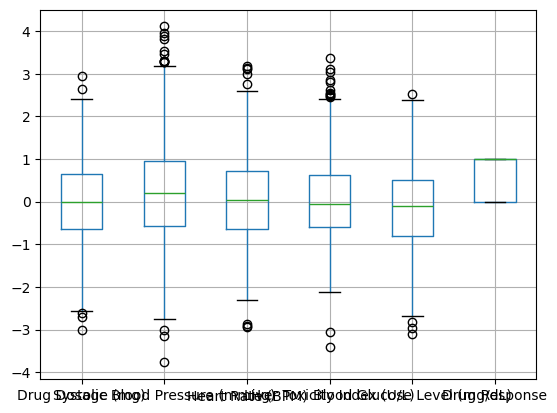

In [7]:
### outliers 

df.boxplot()
plt.show()

In [8]:
def outlier_capping(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3-Q1
    Lower_Extreme = Q1-1.5*IQR
    Upper_Extreme = Q3+1.5*IQR
    df[column] = df[column].apply(lambda x: Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

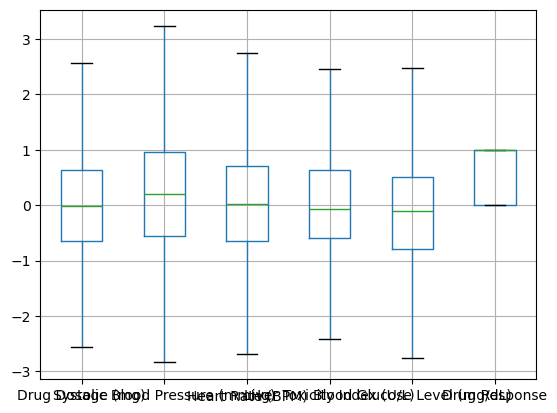

In [9]:
df.boxplot()
plt.show()

In [10]:
num_col = df.select_dtypes(include=['int','float']).columns
num_col

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

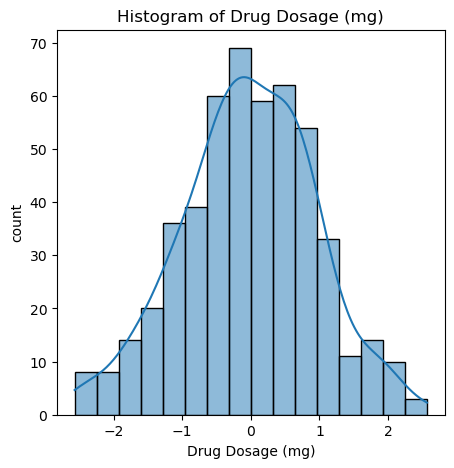

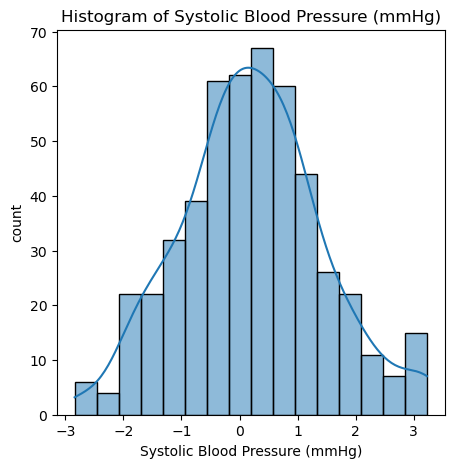

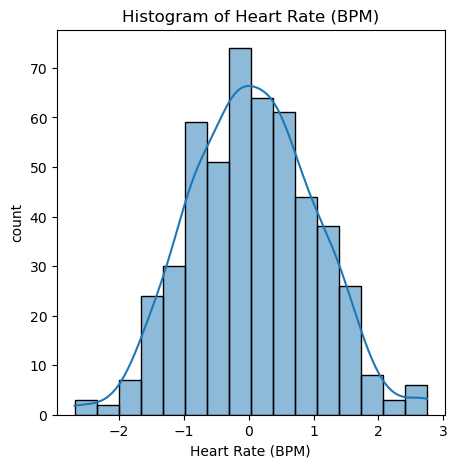

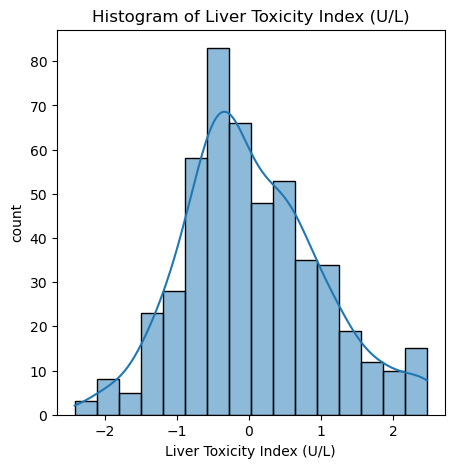

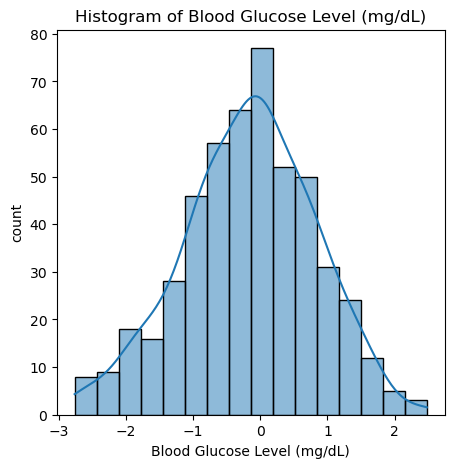

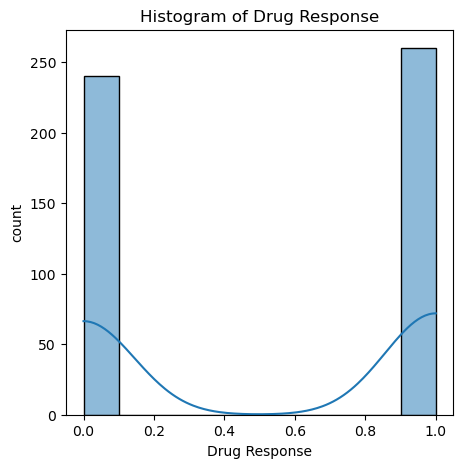

In [11]:
### Histogram 

for i in ['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response']:
    plt.figure(figsize = (5,5))
    sns.histplot(x=df[i],kde = True)
    plt.xlabel(i)
    plt.ylabel('count')
    plt.title(f'Histogram of {i}')
    plt.show()


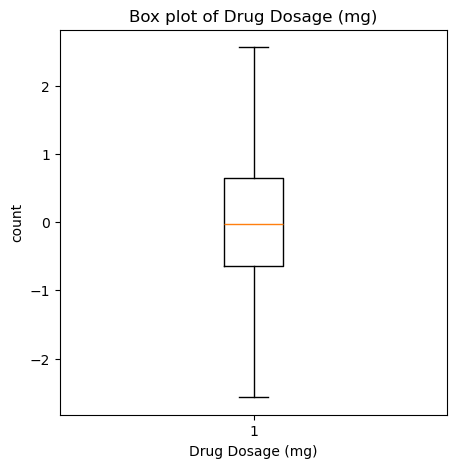

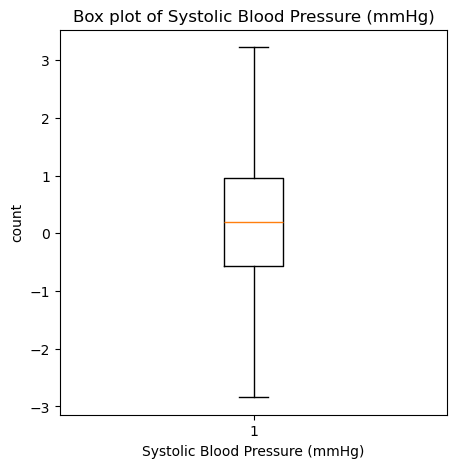

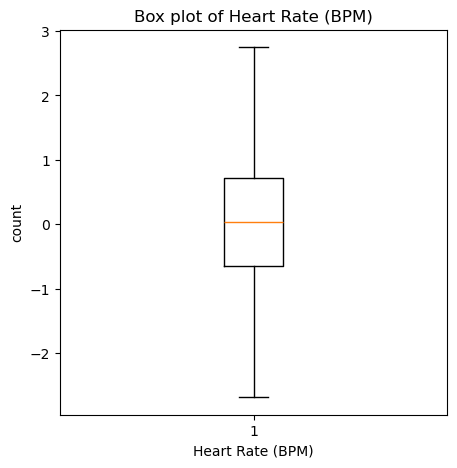

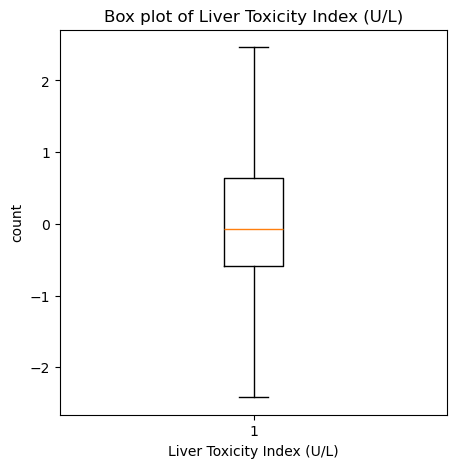

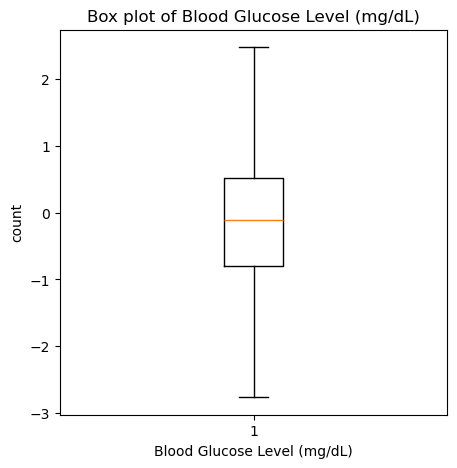

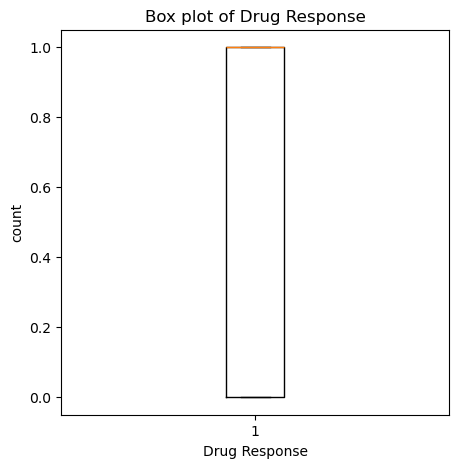

In [12]:
### Box plot 

for i in ['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response']:
    plt.figure(figsize = (5,5))
    plt.boxplot(x=df[i])
    plt.xlabel(i)
    plt.ylabel('count')
    plt.title(f'Box plot of {i}')
    plt.show()

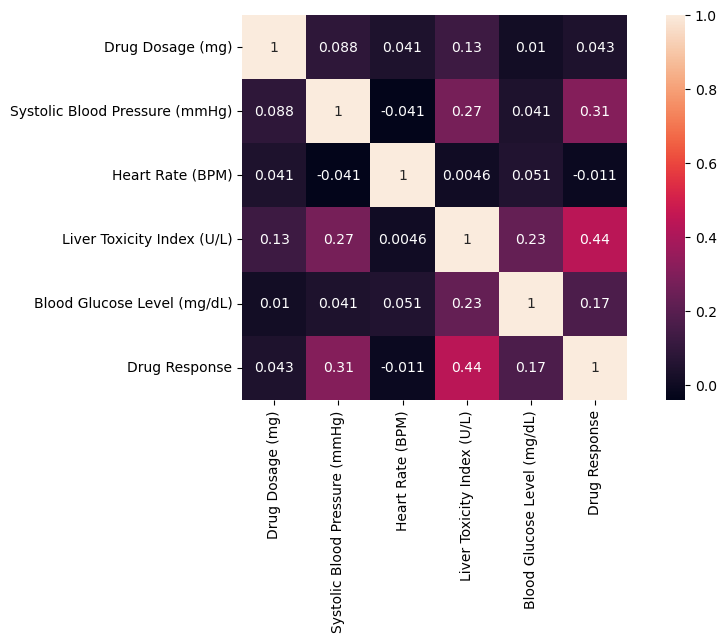

In [13]:

plt.figure(figsize=(10,5))
sns.heatmap(df.corr(),annot=True)
plt.imshow(df.corr())
plt.show()

In [14]:
### Data Preprocessing

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
cat_col = df.select_dtypes(include=['object']).columns
cat_col

Index([], dtype='object')

In [17]:
feature = df.drop(columns=['Drug Response'])
target = df['Drug Response']

In [18]:
feature.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011
1,-1.846188,2.865142,-0.929511,2.463913,-0.719447
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355
4,0.377100,0.538410,-0.029263,1.896015,-0.960130


In [19]:
### Train_test_split

x_train,x_test,y_train,y_test = train_test_split(feature,target,train_size=0.75,random_state=50)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(375, 5)
(125, 5)
(375,)
(125,)


In [20]:
### Data Visualization 

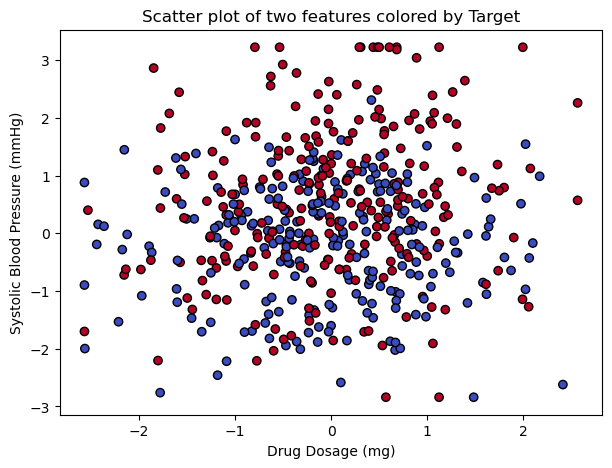

In [21]:
plt.figure(figsize=(7,5))
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=df['Drug Response'], cmap='coolwarm', edgecolors='k')
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Scatter plot of two features colored by Target")
plt.show()

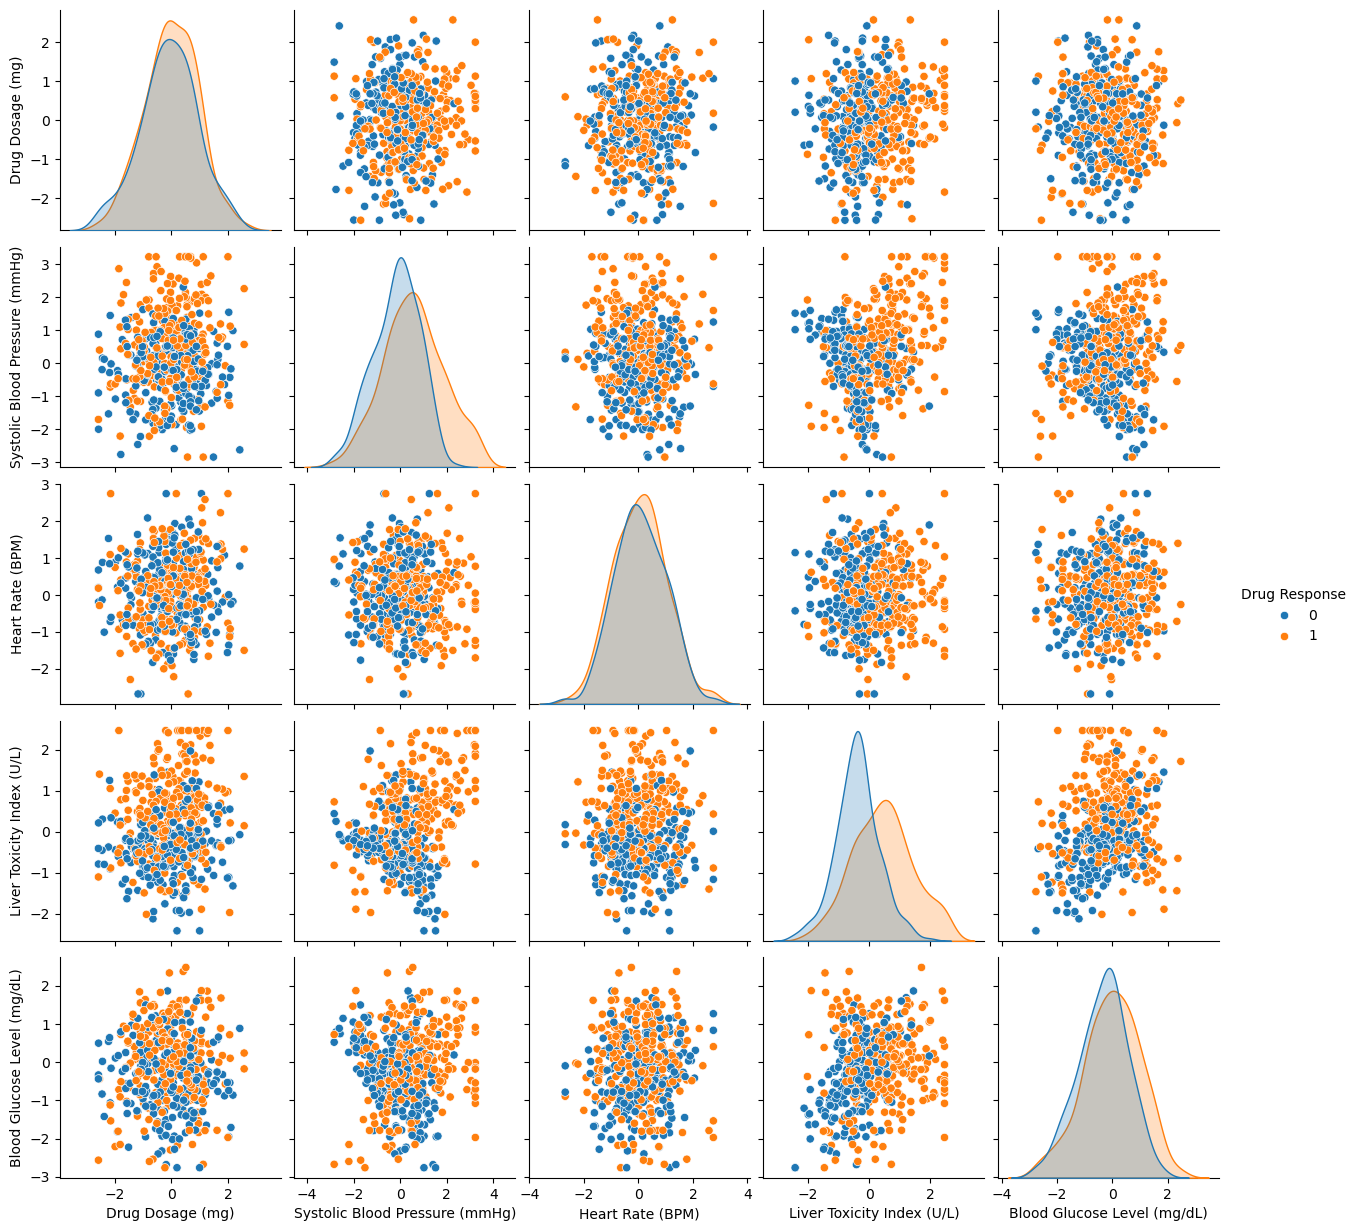

In [22]:
sns.pairplot(df,hue='Drug Response')
plt.show()

In [23]:
import warnings 
warnings.filterwarnings('ignore')

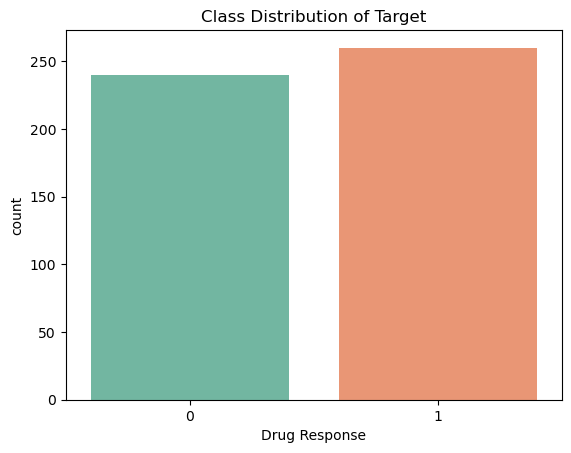

In [24]:
sns.countplot(x="Drug Response", data=df, palette="Set2")
plt.title("Class Distribution of Target")
plt.show()

In [25]:
### SVM Implementation 

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score

In [27]:
svc=SVC(C=5,kernel='poly',gamma=0.1)
svc.fit(x_train,y_train)

,C,5
,kernel,'poly'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [28]:
y_pred = svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.752

In [29]:
### Grid Search 

In [30]:
from sklearn.model_selection import GridSearchCV

In [31]:
params = {'C':range(1,10),'kernel':['linear', 'poly', 'rbf', 'sigmoid'],'gamma':np.arange(0,0.5,0.1)}
grid_search=GridSearchCV(svc,params)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'C': 6, 'gamma': np.float64(0.2), 'kernel': 'rbf'}

In [32]:
### Metrics

In [33]:
svc=SVC(C=6,kernel='rbf',gamma=0.2)
svc.fit(x_train,y_train)
y_pred = svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.776

In [34]:
svc=SVC(C=6,kernel='rbf',gamma=0.2)
svc.fit(x_train,y_train)
y_pred = svc.predict(x_test)
accuracy_score(y_test,y_pred)

0.776

In [35]:
svc=SVC(C=6,kernel='rbf',gamma=0.2)
svc.fit(x_train,y_train)
pre_pred = svc.predict(x_test)
precision_score(y_test,pre_pred)

0.8245614035087719

In [36]:
svc=SVC(C=6,kernel='rbf',gamma=0.2)
svc.fit(x_train,y_train)
f1_pred = svc.predict(x_test)
f1_score(y_test,f1_pred)

0.7704918032786885

In [37]:
svc=SVC(C=6,kernel='rbf',gamma=0.2)
svc.fit(x_train,y_train)
recall_pred = svc.predict(x_test)
recall_score(y_test,recall_pred)

0.7230769230769231

In [38]:
### Visualization of Result

In [39]:
from sklearn.decomposition import PCA

In [40]:
pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

In [42]:
svc = SVC(kernel="linear", random_state=42)
svc.fit(x_train_pca, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [43]:
x_min, x_max = x_test_pca[:, 0].min() - 1, x_test_pca[:, 0].max() + 1
y_min, y_max = x_test_pca[:, 1].min() - 1, x_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

In [44]:
Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

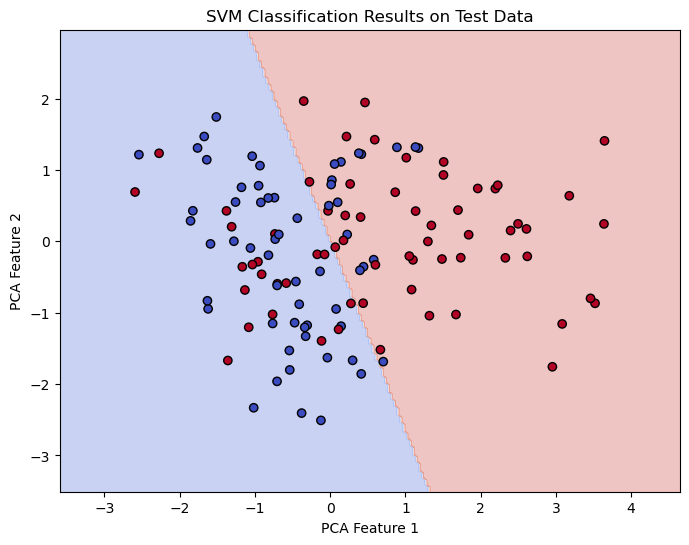

In [47]:
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(x_test_pca[:, 0], x_test_pca[:, 1], c=y_test, cmap="coolwarm", edgecolors="k")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.title("SVM Classification Results on Test Data")
plt.show()

In [48]:
### Hyper Parameter Tuning 

In [49]:
from sklearn.metrics import classification_report

In [50]:
svc=SVC(C=6,kernel='rbf',gamma=0.2)
svc.fit(x_train,y_train)
class_pred = svc.predict(x_test)
classification_report(y_test,recall_pred)

'              precision    recall  f1-score   support\n\n           0       0.74      0.83      0.78        60\n           1       0.82      0.72      0.77        65\n\n    accuracy                           0.78       125\n   macro avg       0.78      0.78      0.78       125\nweighted avg       0.78      0.78      0.78       125\n'

In [51]:
results = pd.DataFrame(grid_search.cv_results_)
pivot = results.pivot_table(values='mean_test_score', index='param_C', columns='param_kernel')

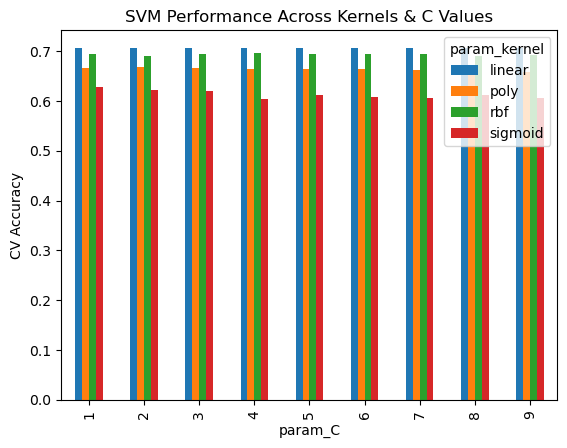

In [52]:
pivot.plot(kind='bar')
plt.ylabel("CV Accuracy")
plt.title("SVM Performance Across Kernels & C Values")
plt.show()

In [ ]:
### Kernel Comparison
Linear: Simple and fast, but may miss nonlinear patterns.
Polynomial: Captures feature interactions, but slower and prone to overfitting.
RBF: Most flexible, handles nonlinear drug–response patterns well, usually best accuracy

In [ ]:
### Strengths & Weaknesses

Strengths: Works well in high-dimensional data, good for clear class separation, robust with proper tuning.
Weaknesses: Sensitive to hyperparameters, less interpretable, not ideal for very large or imbalanced datasets.

In [ ]:
### Practical Implications

In pharma, SVM can predict patient drug response effectively, supporting personalized medicine.
However, real-world deployment needs balancing techniques and interpretability tools to complement SVM.